In [320]:
import pandas as pd

In [321]:
df = pd.read_csv('Telco-Customer-Churn')

In [322]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [323]:
df = df.drop('customerID',axis=1)

In [324]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df["MultipleLines"] = df['MultipleLines'].replace("No phone service","No")

In [325]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [326]:
X = df.drop('Churn', axis=1)
y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [327]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [328]:
X_encode = pd.get_dummies(X, columns= X.select_dtypes(include='object').columns, drop_first=True)

In [329]:
X_encode.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,True,...,False,False,False,False,False,False,True,False,True,False


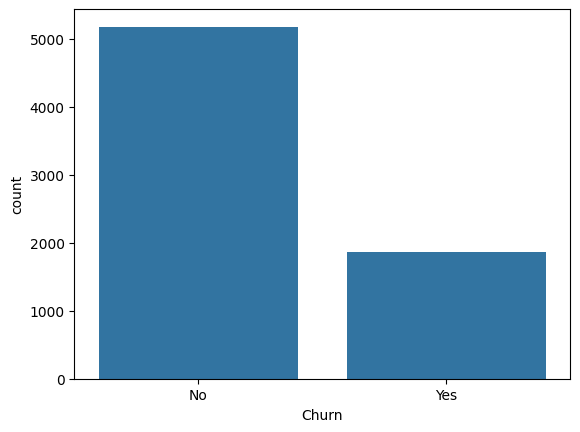

In [330]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Churn', data=df)
plt.show()

In [331]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encode, y, test_size=0.2, random_state=42, stratify=y)

In [332]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)


In [333]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scale)
X_test_pca = pca.transform(X_test_scale)


In [334]:
X_train_pca.shape

(5634, 17)

0.7899219304471257


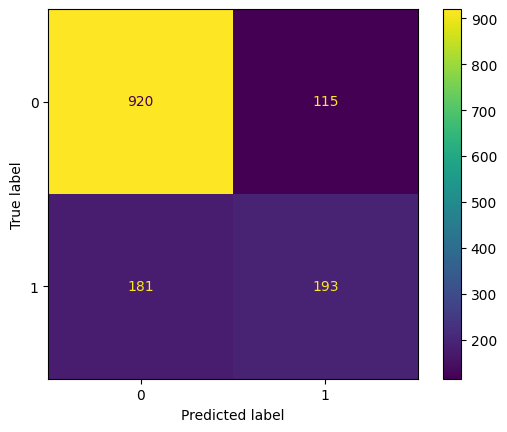

In [336]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

print(accuracy_score(y_test,y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

results=[]
results.append({
    'Model': 'LogisticRegression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Score:
0.6191388008535487
0.7409510290986515


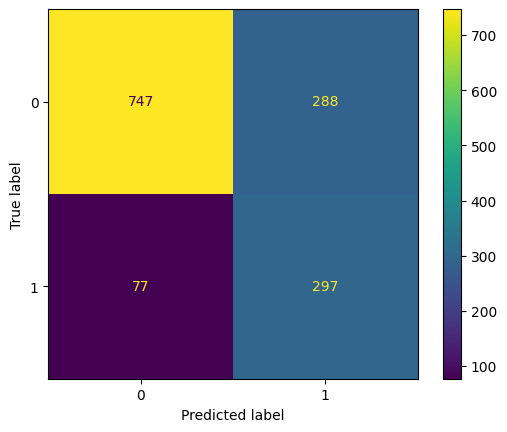

In [337]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier()

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': ['balanced']
}
grid = GridSearchCV(estimator=tree,param_grid=param_grid,scoring='f1',cv=5, verbose=1,n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV Score:")
print(grid.best_score_)

best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)
print(accuracy_score(y_pred, y_test))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))


results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})


0.7388218594748048


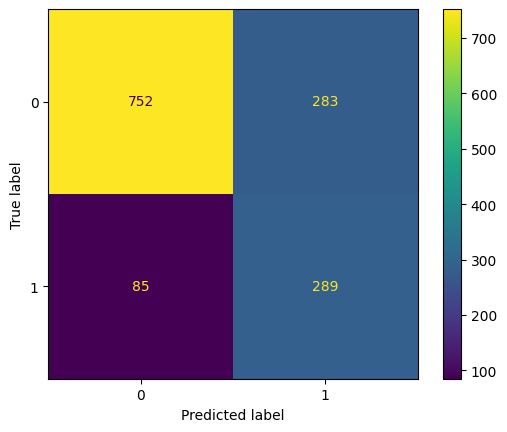

In [338]:
from sklearn.svm import SVC

model = SVC(class_weight='balanced')
model = model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)
print(accuracy_score(y_pred, y_test))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))


results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})


0.7686302342086586


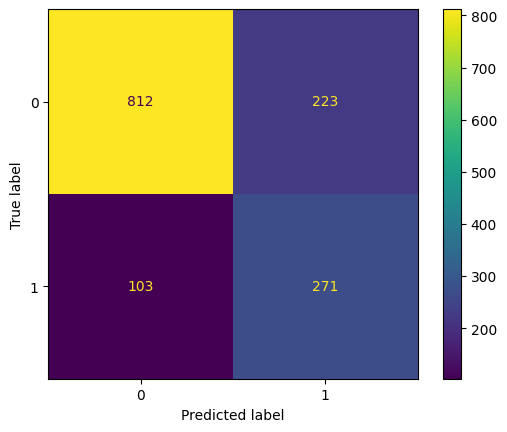

In [339]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300,class_weight='balanced',max_depth=10)
model = model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_pred, y_test))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))


results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})


0.7970191625266146


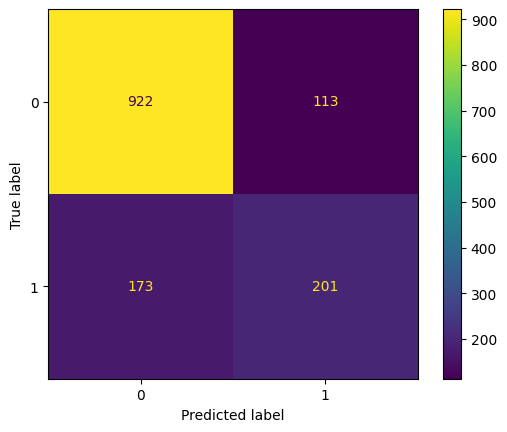

In [340]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=300,learning_rate=0.05)
model = model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_pred, y_test))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))


results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})


0.759403832505323


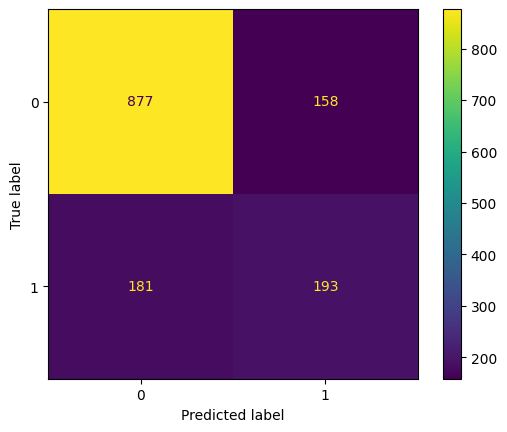

In [341]:
from sklearn.neighbors import KNeighborsClassifier


model = KNeighborsClassifier(n_neighbors=7)
model = model.fit(X_train_scale, y_train)

y_pred = model.predict(X_test_scale)
print(accuracy_score(y_pred, y_test))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))


results.append({
    'Model': ' KNN',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})


0.7558552164655784


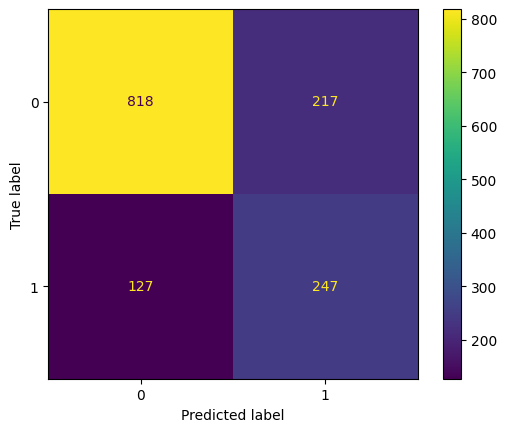

In [342]:
from sklearn.naive_bayes import GaussianNB


model = GaussianNB()
model = model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)
print(accuracy_score(y_pred, y_test))
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))


results.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})


In [348]:
result = pd.DataFrame(results)
result = result.sort_values(
    by='F1 Score',
    ascending=False
)

result.reset_index(drop=True,inplace=True)
print(result)

                Model  Accuracy  Precision    Recall  F1 Score
0       Random Forest  0.768630   0.548583  0.724599  0.624424
1       Decision Tree  0.740951   0.507692  0.794118  0.619395
2                 SVM  0.738822   0.505245  0.772727  0.610994
3         Naive Bayes  0.755855   0.532328  0.660428  0.589499
4             XGBoost  0.797019   0.640127  0.537433  0.584302
5  LogisticRegression  0.789922   0.626623  0.516043  0.565982
6                 KNN  0.759404   0.549858  0.516043  0.532414
